# Experiment A — CNN Binary Classifier: BPSK Device Fingerprinting
**Thesis:** Lightweight Device Authentication in Wireless Communication Using RF Fingerprinting  
**Authors:** Amitha · Tharangi Madushani  
**Supervisor:** Prof. Qinghua Wang  

---

## Experiment scope

- **Task:** Binary classification — DEV01 vs DEV02  
- **Modulation:** BPSK only (most reliable CFO separation confirmed in analysis)  
- **Input:** Session 1 clean data (`BPSK_clean_X.npy`) — 100,000 windows of shape (128, 2)  
- **Split:** Stratified 70 / 15 / 15 — train / val / test  
- **SNR robustness:** Train once on clean; evaluate same trained model at SNR 20 / 10 / 0 dB  

## CNN architecture (thesis Chapter 3)

| Layer | Config | Output shape |
|---|---|---|
| Input | — | (128, 2) |
| Conv1D + AvgPool | 32 filters, k=7, valid | (61, 32) |
| Conv1D + AvgPool | 64 filters, k=5, valid | (28, 64) |
| Conv1D + AvgPool | 128 filters, k=3, valid | (13, 128) |
| GlobalAvgPool1D | — | (128,) |
| Dense + Dropout 0.5 | 64 units ReLU | (64,) |
| Dense output | 2 units Softmax | (2,) |
| **Total params** | | **~44,000** |

## Section 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


## Section 2 — Configuration

In [2]:
import os

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE         = '/content/drive/MyDrive/My Thesis'
PREPROCESSED = os.path.join(BASE, 'Preprocessed')
OUTPUT_DIR   = os.path.join(BASE, 'Models', 'ExperimentA')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Experiment settings ────────────────────────────────────────────────────────
TRAIN_SESSION  = 'S1'          # session used for training and in-session testing
MODULATION     = 'BPSK'        # Experiment A: single modulation
SNR_LEVELS     = [None, 20, 10, 0]   # None = clean; others for robustness sweep

# ── Split ──────────────────────────────────────────────────────────────────────
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# TEST_FRAC  = 0.15  (remainder)

# ── Training hyperparameters ───────────────────────────────────────────────────
LEARNING_RATE    = 1e-4
BATCH_SIZE       = 256
MAX_EPOCHS       = 100
EARLY_STOP_PAT   = 10        # patience for EarlyStopping on val_loss
RANDOM_SEED      = 42

print('Configuration loaded.')
print(f'  Train session : {TRAIN_SESSION}')
print(f'  Modulation    : {MODULATION}')
print(f'  Split         : {int(TRAIN_FRAC*100)}/{int(VAL_FRAC*100)}/{int((1-TRAIN_FRAC-VAL_FRAC)*100)}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Max epochs    : {MAX_EPOCHS}')
print(f'  LR            : {LEARNING_RATE}')
print(f'  Output dir    : {OUTPUT_DIR}')

Configuration loaded.
  Train session : S1
  Modulation    : BPSK
  Split         : 70/15/15
  Batch size    : 256
  Max epochs    : 100
  LR            : 0.0001
  Output dir    : /content/drive/MyDrive/My Thesis/Models/ExperimentA


## Section 3 — Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {keras.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU available: {gpus[0].name}')
else:
    print('No GPU detected — running on CPU (slower but fine for this size)')

TensorFlow  : 2.20.0
Keras       : 3.13.2
GPU available: /physical_device:GPU:0


## Section 4 — Load Data and Split

Data was shuffled with `RANDOM_SEED=42` during preprocessing, so device blocks are already interleaved.  
We use a **stratified split** to ensure equal class balance across train / val / test.

In [4]:
# ── Load clean S1 BPSK ────────────────────────────────────────────────────────
x_path = os.path.join(PREPROCESSED, TRAIN_SESSION, f'{MODULATION}_clean_X.npy')
y_path = os.path.join(PREPROCESSED, TRAIN_SESSION, f'{MODULATION}_clean_y.npy')

X_all = np.load(x_path)   # (100000, 128, 2) float32
y_all = np.load(y_path)   # (100000,) int32

print(f'Loaded: {TRAIN_SESSION}/{MODULATION}_clean')
print(f'  X shape : {X_all.shape}   dtype: {X_all.dtype}')
print(f'  y shape : {y_all.shape}   dtype: {y_all.dtype}')
print(f'  X range : [{X_all.min():.4f}, {X_all.max():.4f}]')
print(f'  DEV01 (0): {np.sum(y_all==0):,}   DEV02 (1): {np.sum(y_all==1):,}')

# ── Stratified split: train / val / test ──────────────────────────────────────
# Step 1: carve out test set (15%)
X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X_all, y_all, np.arange(len(y_all)),
    test_size=(1 - TRAIN_FRAC - VAL_FRAC),
    stratify=y_all,
    random_state=RANDOM_SEED
)

# Step 2: split remainder into train and val
val_relative = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_relative,
    stratify=y_trainval,
    random_state=RANDOM_SEED
)

print(f'\nSplit summary:')
print(f'  Train : {X_train.shape[0]:,}  ({X_train.shape[0]/len(y_all)*100:.1f}%)')
print(f'  Val   : {X_val.shape[0]:,}  ({X_val.shape[0]/len(y_all)*100:.1f}%)')
print(f'  Test  : {X_test.shape[0]:,}  ({X_test.shape[0]/len(y_all)*100:.1f}%)')
print(f'  Train class balance: DEV01={np.sum(y_train==0):,}  DEV02={np.sum(y_train==1):,}')
print(f'  Test  class balance: DEV01={np.sum(y_test==0):,}   DEV02={np.sum(y_test==1):,}')

Loaded: S1/BPSK_clean
  X shape : (100000, 128, 2)   dtype: float32
  y shape : (100000,)   dtype: int32
  X range : [-0.9877, 0.9858]
  DEV01 (0): 50,000   DEV02 (1): 50,000

Split summary:
  Train : 69,999  (70.0%)
  Val   : 15,000  (15.0%)
  Test  : 15,001  (15.0%)
  Train class balance: DEV01=34,999  DEV02=35,000
  Test  class balance: DEV01=7,501   DEV02=7,500


## Section 5 — CNN Architecture (Thesis Chapter 3)

In [5]:
def build_cnn(input_shape=(128, 2), num_classes=2, learning_rate=1e-4):
    """
    Lightweight 1D CNN for RF device fingerprinting.

    Architecture matches thesis Chapter 3:
    - Three Conv1D + AveragePooling1D blocks (valid padding)
    - GlobalAveragePooling1D (not Flatten — preserves spatial generalisation)
    - Dense(64, ReLU) + Dropout(0.5)
    - Dense(2, Softmax)
    """
    inputs = keras.Input(shape=input_shape, name='iq_input')

    # Block 1: 32 filters, kernel=7
    x = layers.Conv1D(32, kernel_size=7, padding='valid',
                      activation='relu', name='conv1')(inputs)
    x = layers.AveragePooling1D(pool_size=2, name='pool1')(x)

    # Block 2: 64 filters, kernel=5
    x = layers.Conv1D(64, kernel_size=5, padding='valid',
                      activation='relu', name='conv2')(x)
    x = layers.AveragePooling1D(pool_size=2, name='pool2')(x)

    # Block 3: 128 filters, kernel=3
    x = layers.Conv1D(128, kernel_size=3, padding='valid',
                      activation='relu', name='conv3')(x)
    x = layers.AveragePooling1D(pool_size=2, name='pool3')(x)

    # Aggregate temporal dimension
    x = layers.GlobalAveragePooling1D(name='global_avg')(x)

    # Classifier head
    x = layers.Dense(64, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.5, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='RFF_CNN_ExperimentA')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_cnn(learning_rate=LEARNING_RATE)
model.summary()

total_params = model.count_params()
print(f'\nTotal parameters: {total_params:,}')

Model: "RFF_CNN_ExperimentA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ iq_input (InputLayer)           │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 122, 32)        │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling1D)        │ (None, 61, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 57, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling1D)        │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 26, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (AveragePooling1D)        │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg                      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,874 (171.38 KB)

 Trainable params: 43,874 (171.38 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 43,874


## Section 6 — Train on Clean S1 BPSK

In [6]:
model_path = os.path.join(OUTPUT_DIR, 'best_model.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOP_PAT,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print('Training started...')
t_start = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - t_start
print(f'\nTraining complete in {elapsed/60:.1f} min')
print(f'Best model saved to: {model_path}')

Training started...
Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6867 - loss: 0.6393 - val_accuracy: 0.8457 - val_loss: 0.4832 - learning_rate: 1.0000e-04
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8688 - loss: 0.3548 - val_accuracy: 0.9009 - val_loss: 0.2304 - learning_rate: 1.0000e-04
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9019 - loss: 0.2050 - val_accuracy: 0.9034 - val_loss: 0.1630 - learning_rate: 1.0000e-04
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9077 - loss: 0.1682 - val_accuracy: 0.9272 - val_loss: 0.1453 - learning_rate: 1.0000e-04
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9136 - loss: 0.1548 - val_accuracy: 0.9279 - val_loss: 0.1370 - learning_rate: 1.0000e-04
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9147 - loss: 0.1487 - val_accuracy: 0.9289 - val_loss: 0.1327 - learning_rate: 1.0000e-04
Epoch 7/100
274/274 ━━━━━━━━━━━━━━━━

## Section 7 — Training Curves

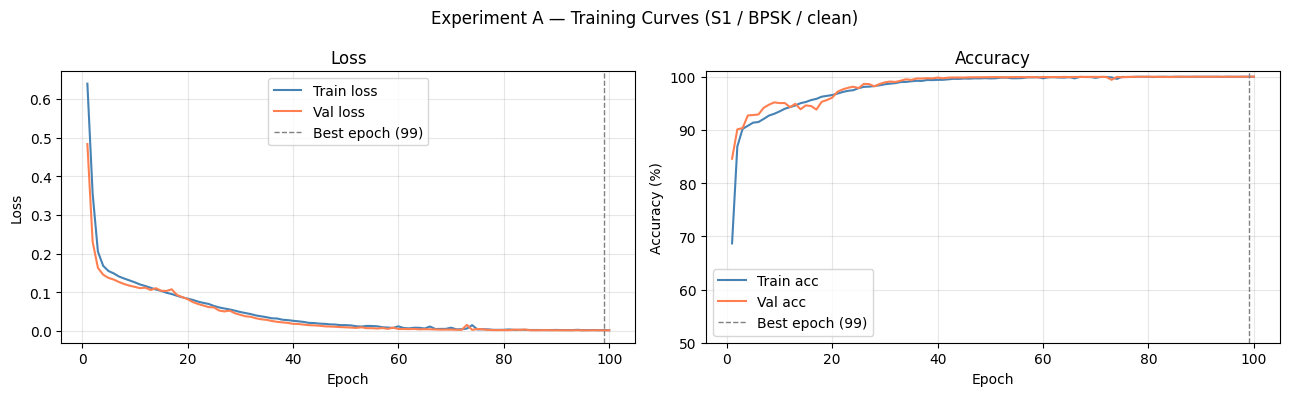

Best val loss  : 0.0013  at epoch 99
Best val acc   : 100.00%
Plot saved     : /content/drive/MyDrive/My Thesis/Models/ExperimentA/training_curves.png


In [7]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)
best_epoch = np.argmin(hist['val_loss']) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Experiment A — Training Curves ({TRAIN_SESSION} / {MODULATION} / clean)',
             fontsize=12)

# Loss
ax1.plot(epochs_ran, hist['loss'],     label='Train loss', color='steelblue')
ax1.plot(epochs_ran, hist['val_loss'], label='Val loss',   color='coral')
ax1.axvline(best_epoch, linestyle='--', color='grey', linewidth=1,
            label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_ran, [a*100 for a in hist['accuracy']],
         label='Train acc', color='steelblue')
ax2.plot(epochs_ran, [a*100 for a in hist['val_accuracy']],
         label='Val acc',   color='coral')
ax2.axvline(best_epoch, linestyle='--', color='grey', linewidth=1,
            label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.set_ylim([50, 101])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Best val loss  : {min(hist["val_loss"]):.4f}  at epoch {best_epoch}')
print(f'Best val acc   : {max(hist["val_accuracy"])*100:.2f}%')
print(f'Plot saved     : {plot_path}')

## Section 8 — Evaluate on Clean Test Set

In [8]:
# ── Overall metrics ───────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

print(f'=== Clean Test Set Results ({TRAIN_SESSION}/{MODULATION}) ===')
print(f'  Test loss     : {test_loss:.4f}')
print(f'  Test accuracy : {test_acc*100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['DEV01', 'DEV02']))

=== Clean Test Set Results (S1/BPSK) ===
  Test loss     : 0.0010
  Test accuracy : 99.99%

              precision    recall  f1-score   support

       DEV01       1.00      1.00      1.00      7501
       DEV02       1.00      1.00      1.00      7500

    accuracy                           1.00     15001
   macro avg       1.00      1.00      1.00     15001
weighted avg       1.00      1.00      1.00     15001



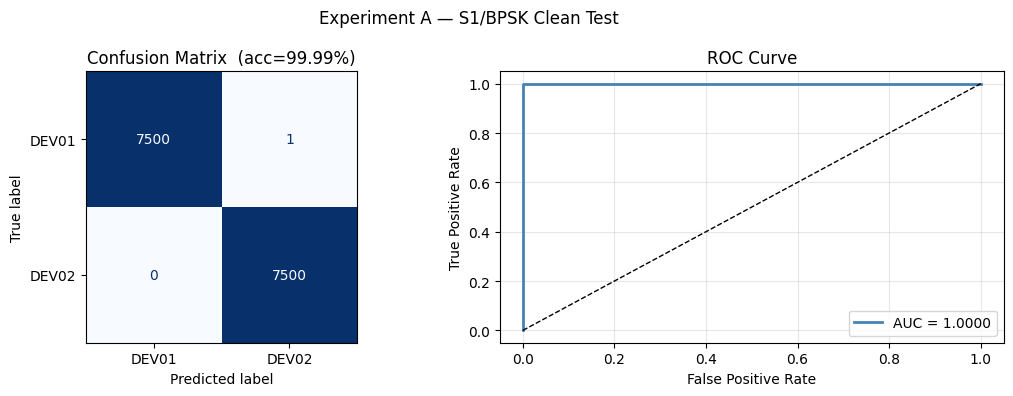

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/clean_test_cm_roc.png
ROC AUC: 1.0000


In [9]:
# ── Confusion matrix + ROC ────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
roc_auc     = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'Experiment A — {TRAIN_SESSION}/{MODULATION} Clean Test', fontsize=12)

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DEV01', 'DEV02'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title(f'Confusion Matrix  (acc={test_acc*100:.2f}%)')

# ROC curve
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'clean_test_cm_roc.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')
print(f'ROC AUC: {roc_auc:.4f}')

## Section 9 — SNR Robustness Sweep

The model trained on clean data is evaluated **without retraining** on the noisy test sets.  
The same test indices are used across all SNR levels — only the X values differ (noise injected).  
This directly answers: *how does fingerprinting accuracy degrade under channel noise?*

In [10]:
def snr_label(snr_db):
    return 'clean' if snr_db is None else f'SNR{snr_db}'


snr_results = {}   # snr_db → {accuracy, loss, auc, cm}

# Store clean result first
snr_results[None] = {
    'label'    : 'Clean (∞ dB)',
    'accuracy' : float(test_acc),
    'loss'     : float(test_loss),
    'auc'      : float(roc_auc),
    'cm'       : cm.tolist()
}

print(f'  Clean (∞ dB)  →  acc={test_acc*100:.2f}%  AUC={roc_auc:.4f}')

# Evaluate at each noisy SNR
for snr in [20, 10, 0]:
    tag    = snr_label(snr)
    x_path = os.path.join(PREPROCESSED, TRAIN_SESSION, f'{MODULATION}_{tag}_X.npy')
    y_path = os.path.join(PREPROCESSED, TRAIN_SESSION, f'{MODULATION}_{tag}_y.npy')

    X_noisy_all = np.load(x_path)
    # y is identical across SNR levels — reuse y_test indices from the clean split
    # idx_test was captured during the stratified split in Section 4
    X_noisy_test = X_noisy_all[idx_test]
    del X_noisy_all   # free RAM

    loss_n, acc_n     = model.evaluate(X_noisy_test, y_test,
                                       batch_size=BATCH_SIZE, verbose=0)
    prob_n            = model.predict(X_noisy_test, batch_size=BATCH_SIZE, verbose=0)
    pred_n            = np.argmax(prob_n, axis=1)
    cm_n              = confusion_matrix(y_test, pred_n)
    fpr_n, tpr_n, _   = roc_curve(y_test, prob_n[:, 1])
    auc_n             = auc(fpr_n, tpr_n)

    snr_results[snr] = {
        'label'    : f'SNR {snr} dB',
        'accuracy' : float(acc_n),
        'loss'     : float(loss_n),
        'auc'      : float(auc_n),
        'cm'       : cm_n.tolist()
    }
    print(f'  SNR {snr:>2} dB      →  acc={acc_n*100:.2f}%  AUC={auc_n:.4f}')
    del X_noisy_test, prob_n

print('\nSNR sweep complete.')

  Clean (∞ dB)  →  acc=99.99%  AUC=1.0000
  SNR 20 dB      →  acc=99.01%  AUC=0.9997
  SNR 10 dB      →  acc=92.97%  AUC=0.9858
  SNR  0 dB      →  acc=83.17%  AUC=0.9142

SNR sweep complete.


## Section 10 — Accuracy vs SNR Plot

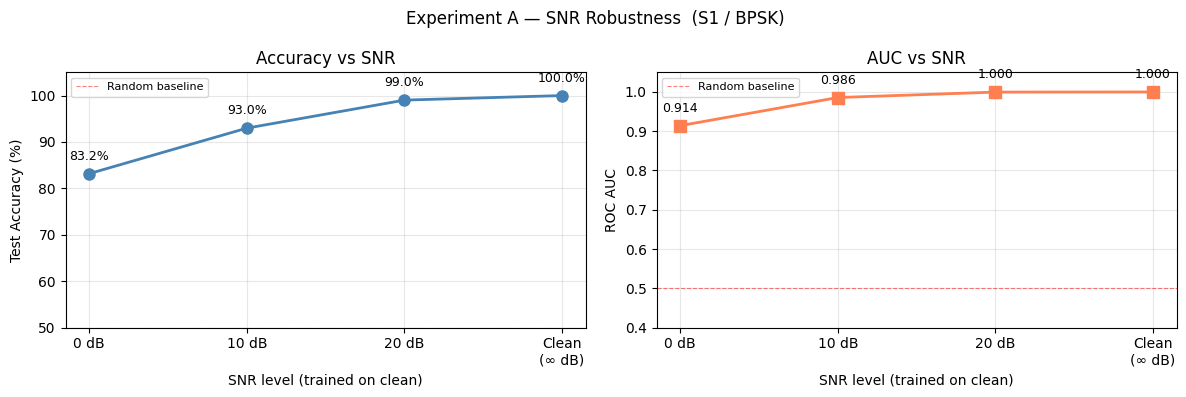

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/accuracy_vs_snr.png


In [11]:
# ── Accuracy vs SNR line chart ─────────────────────────────────────────────────
snr_labels  = ['0 dB', '10 dB', '20 dB', 'Clean\n(∞ dB)']
snr_keys    = [0, 10, 20, None]
accuracies  = [snr_results[k]['accuracy'] * 100 for k in snr_keys]
aucs        = [snr_results[k]['auc']            for k in snr_keys]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Experiment A — SNR Robustness  ({TRAIN_SESSION} / {MODULATION})',
             fontsize=12)

# Accuracy
ax1.plot(range(len(snr_labels)), accuracies,
         marker='o', color='steelblue', linewidth=2, markersize=8)
for i, (lbl, acc) in enumerate(zip(snr_labels, accuracies)):
    ax1.annotate(f'{acc:.1f}%', (i, acc),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax1.set_xticks(range(len(snr_labels)))
ax1.set_xticklabels(snr_labels)
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_xlabel('SNR level (trained on clean)')
ax1.set_title('Accuracy vs SNR')
ax1.set_ylim([50, 105])
ax1.axhline(50, linestyle='--', color='red', linewidth=0.8, alpha=0.5,
            label='Random baseline')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# AUC
ax2.plot(range(len(snr_labels)), aucs,
         marker='s', color='coral', linewidth=2, markersize=8)
for i, (lbl, a) in enumerate(zip(snr_labels, aucs)):
    ax2.annotate(f'{a:.3f}', (i, a),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax2.set_xticks(range(len(snr_labels)))
ax2.set_xticklabels(snr_labels)
ax2.set_ylabel('ROC AUC')
ax2.set_xlabel('SNR level (trained on clean)')
ax2.set_title('AUC vs SNR')
ax2.set_ylim([0.4, 1.05])
ax2.axhline(0.5, linestyle='--', color='red', linewidth=0.8, alpha=0.5,
            label='Random baseline')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'accuracy_vs_snr.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

## Section 11 — Confusion Matrices at Each SNR

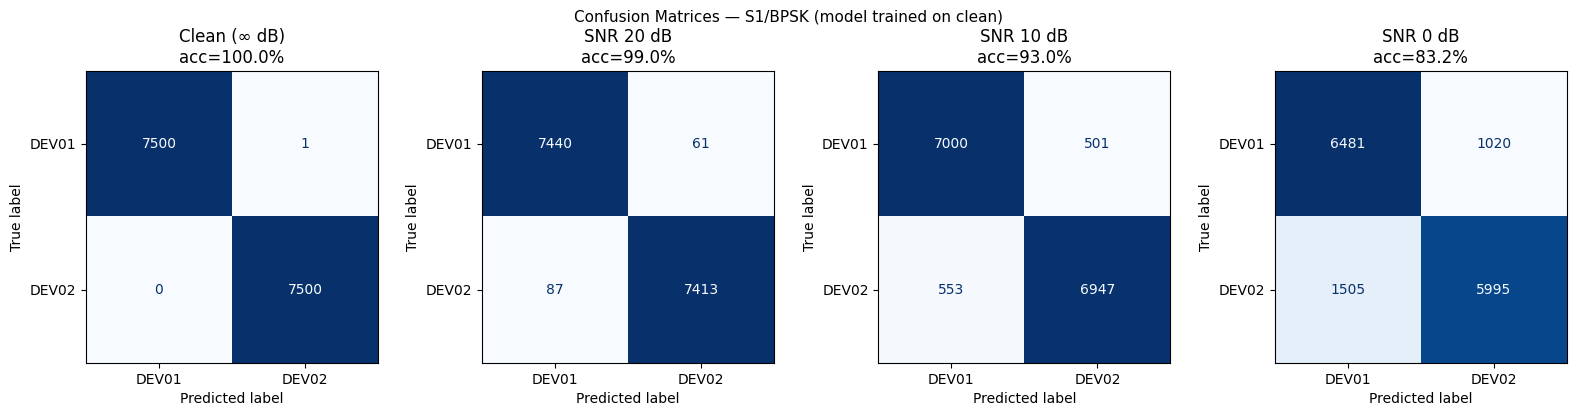

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/confusion_matrices_snr.png


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'Confusion Matrices — {TRAIN_SESSION}/{MODULATION} (model trained on clean)',
             fontsize=11)

for ax, key in zip(axes, [None, 20, 10, 0]):
    r   = snr_results[key]
    cm_ = np.array(r['cm'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_,
                                  display_labels=['DEV01', 'DEV02'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['label']}\nacc={r['accuracy']*100:.1f}%")

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'confusion_matrices_snr.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

## Section 12 — Save Model and Results

In [13]:
# ── Save results JSON ──────────────────────────────────────────────────────────
results_dict = {
    'experiment'    : 'A',
    'modulation'    : MODULATION,
    'train_session' : TRAIN_SESSION,
    'total_params'  : int(model.count_params()),
    'best_epoch'    : int(best_epoch),
    'val_accuracy'  : float(max(hist['val_accuracy'])),
    'val_loss'      : float(min(hist['val_loss'])),
    'snr_results'   : {
        str(k) if k is not None else 'clean': v
        for k, v in snr_results.items()
    },
    'split' : {
        'train_n' : int(X_train.shape[0]),
        'val_n'   : int(X_val.shape[0]),
        'test_n'  : int(X_test.shape[0]),
    }
}

json_path = os.path.join(OUTPUT_DIR, 'experiment_A_results.json')
with open(json_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f'Results saved  : {json_path}')
print(f'Model saved    : {model_path}')

# ── Final summary ──────────────────────────────────────────────────────────────
print()
print('═' * 50)
print('  EXPERIMENT A SUMMARY')
print('═' * 50)
print(f'  Modulation        : {MODULATION}')
print(f'  Train session     : {TRAIN_SESSION}')
print(f'  Total params      : {model.count_params():,}')
print(f'  Best epoch        : {best_epoch}')
print(f'  Val accuracy      : {max(hist["val_accuracy"])*100:.2f}%')
print()
print(f'  {"SNR":<15} {"Accuracy":>10} {"AUC":>8}')
print(f'  {"-"*35}')
for key in [None, 20, 10, 0]:
    r   = snr_results[key]
    lbl = r['label']
    print(f'  {lbl:<15} {r["accuracy"]*100:>9.2f}% {r["auc"]:>8.4f}')
print('═' * 50)

Results saved  : /content/drive/MyDrive/My Thesis/Models/ExperimentA/experiment_A_results.json
Model saved    : /content/drive/MyDrive/My Thesis/Models/ExperimentA/best_model.keras

══════════════════════════════════════════════════
  EXPERIMENT A SUMMARY
══════════════════════════════════════════════════
  Modulation        : BPSK
  Train session     : S1
  Total params      : 43,874
  Best epoch        : 99
  Val accuracy      : 100.00%

  SNR               Accuracy      AUC
  -----------------------------------
  Clean (∞ dB)        99.99%   1.0000
  SNR 20 dB           99.01%   0.9997
  SNR 10 dB           92.97%   0.9858
  SNR 0 dB            83.17%   0.9142
══════════════════════════════════════════════════


In [14]:
# ── Quick cross-session check ──────────────────────────────────────────────────
X_s2 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_X.npy'))
y_s2 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_y.npy'))

loss_s2, acc_s2 = model.evaluate(X_s2, y_s2, batch_size=BATCH_SIZE, verbose=0)
print(f'Cross-session accuracy (S1 train → S2 test): {acc_s2*100:.2f}%')
print(f'Cross-session loss: {loss_s2:.4f}')

Cross-session accuracy (S1 train → S2 test): 50.00%
Cross-session loss: 71.7109


In [15]:
# ── Multi-session fix: load both sessions ──────────────────────────────────────
import gc

X_s1 = np.load(os.path.join(PREPROCESSED, 'S1', 'BPSK_clean_X.npy'))
y_s1 = np.load(os.path.join(PREPROCESSED, 'S1', 'BPSK_clean_y.npy'))
X_s2 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_X.npy'))
y_s2 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_y.npy'))

# Carve out 20% test from each session independently (stratified)
# This guarantees the test set has both sessions represented
from sklearn.model_selection import train_test_split

X_s1_tr, X_s1_te, y_s1_tr, y_s1_te = train_test_split(
    X_s1, y_s1, test_size=0.20, stratify=y_s1, random_state=RANDOM_SEED)
X_s2_tr, X_s2_te, y_s2_tr, y_s2_te = train_test_split(
    X_s2, y_s2, test_size=0.20, stratify=y_s2, random_state=RANDOM_SEED)

del X_s1, y_s1, X_s2, y_s2
gc.collect()

# Combine train pools and test pools
X_pool = np.concatenate([X_s1_tr, X_s2_tr], axis=0)
y_pool = np.concatenate([y_s1_tr, y_s2_tr], axis=0)
X_te_ms = np.concatenate([X_s1_te, X_s2_te], axis=0)
y_te_ms = np.concatenate([y_s1_te, y_s2_te], axis=0)

del X_s1_tr, X_s2_tr, y_s1_tr, y_s2_tr, X_s1_te, X_s2_te, y_s1_te, y_s2_te
gc.collect()

# Final train / val split from the combined pool
X_tr_ms, X_val_ms, y_tr_ms, y_val_ms = train_test_split(
    X_pool, y_pool, test_size=0.15, stratify=y_pool, random_state=RANDOM_SEED)
del X_pool, y_pool
gc.collect()

print(f'Multi-session split:')
print(f'  Train : {X_tr_ms.shape[0]:,}')
print(f'  Val   : {X_val_ms.shape[0]:,}')
print(f'  Test  : {X_te_ms.shape[0]:,}')
print(f'  Test class balance: DEV01={np.sum(y_te_ms==0):,}  DEV02={np.sum(y_te_ms==1):,}')

Multi-session split:
  Train : 136,000
  Val   : 24,000
  Test  : 40,000
  Test class balance: DEV01=20,000  DEV02=20,000


In [16]:
# ── Retrain with multi-session data ───────────────────────────────────────────
model_ms_path = os.path.join(OUTPUT_DIR, 'best_model_multisession.keras')

model_ms = build_cnn(learning_rate=LEARNING_RATE)

callbacks_ms = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=model_ms_path, monitor='val_loss',
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

print('Retraining on S1 + S2 combined...')
t0 = time.time()

history_ms = model_ms.fit(
    X_tr_ms, y_tr_ms,
    validation_data=(X_val_ms, y_val_ms),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_ms,
    verbose=1
)

print(f'Done in {(time.time()-t0)/60:.1f} min')
print(f'Best val acc: {max(history_ms.history["val_accuracy"])*100:.2f}%')

Retraining on S1 + S2 combined...
Epoch 1/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7069 - loss: 0.6142 - val_accuracy: 0.8271 - val_loss: 0.5160 - learning_rate: 1.0000e-04
Epoch 2/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8346 - loss: 0.4741 - val_accuracy: 0.8485 - val_loss: 0.4147 - learning_rate: 1.0000e-04
Epoch 3/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8478 - loss: 0.3810 - val_accuracy: 0.8554 - val_loss: 0.3151 - learning_rate: 1.0000e-04
Epoch 4/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8852 - loss: 0.2797 - val_accuracy: 0.9284 - val_loss: 0.2037 - learning_rate: 1.0000e-04
Epoch 5/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9294 - loss: 0.1930 - val_accuracy: 0.9630 - val_loss: 0.1368 - learning_rate: 1.0000e-04
Epoch 6/100
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9492 - loss: 0.1413 - val_accuracy: 0.9728 - val_loss: 0.1008 - learning_rate: 1.0000e-04
Epoch 7/100
532/532 ━━

In [17]:
# ── Evaluate retrained model ───────────────────────────────────────────────────
from sklearn.metrics import classification_report

# In-session (combined S1+S2 test set)
loss_ms, acc_ms = model_ms.evaluate(X_te_ms, y_te_ms,
                                     batch_size=BATCH_SIZE, verbose=0)
y_pred_ms = np.argmax(model_ms.predict(X_te_ms, batch_size=BATCH_SIZE, verbose=0), axis=1)

print(f'Multi-session test accuracy : {acc_ms*100:.2f}%')
print(f'Multi-session test loss     : {loss_ms:.4f}')
print()
print(classification_report(y_te_ms, y_pred_ms, target_names=['DEV01', 'DEV02']))

# True cross-session: load full S2 and test (strictest possible test)
X_s2_full = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_X.npy'))
y_s2_full = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_y.npy'))

loss_cs, acc_cs = model_ms.evaluate(X_s2_full, y_s2_full,
                                     batch_size=BATCH_SIZE, verbose=0)
print(f'\nFull S2 cross-session accuracy : {acc_cs*100:.2f}%')
del X_s2_full, y_s2_full
gc.collect()

Multi-session test accuracy : 100.00%
Multi-session test loss     : 0.0001

              precision    recall  f1-score   support

       DEV01       1.00      1.00      1.00     20000
       DEV02       1.00      1.00      1.00     20000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000


Full S2 cross-session accuracy : 100.00%


1402

SNR               Accuracy     Loss
------------------------------------
Clean (∞ dB)       100.00%    0.0000  AUC=1.0000
SNR 20 dB          100.00%    0.0000  AUC=1.0000
SNR 10 dB           99.51%    0.0215  AUC=0.9999
SNR 0 dB            57.26%   10.9697  AUC=0.9187


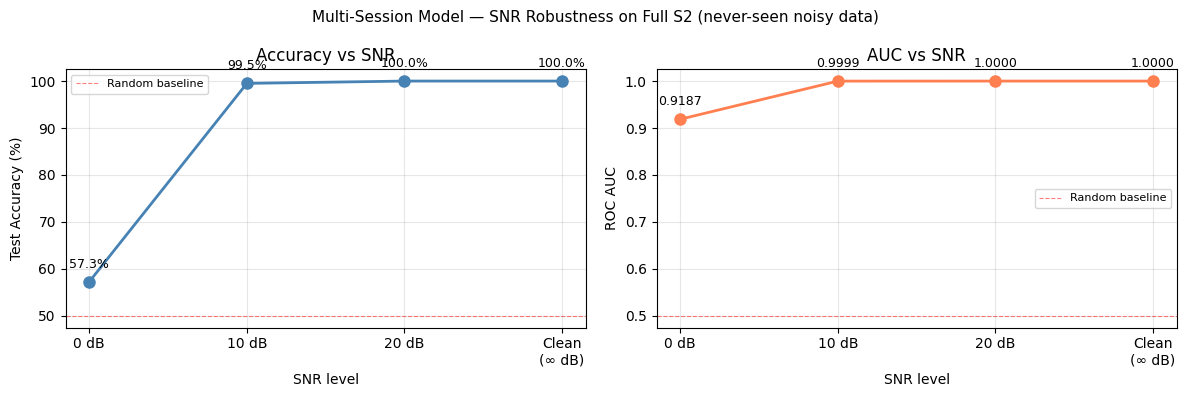

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/multisession_snr_robustness_S2.png


In [18]:
# ── SNR sweep on multi-session model — evaluated on FULL S2 ───────────────────
# S2 noisy files were never seen during training (only S2 clean 80% was in pool)
# This is the strictest possible robustness test

snr_sweep = [None, 20, 10, 0]
ms_snr_results = {}

print(f'{"SNR":<15} {"Accuracy":>10} {"Loss":>8}')
print('-' * 36)

for snr in snr_sweep:
    tag    = 'clean' if snr is None else f'SNR{snr}'
    x_path = os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_X.npy')
    y_path = os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_y.npy')

    X_snr = np.load(x_path)
    y_snr = np.load(y_path)

    loss_snr, acc_snr = model_ms.evaluate(X_snr, y_snr,
                                           batch_size=BATCH_SIZE, verbose=0)
    y_prob = model_ms.predict(X_snr, batch_size=BATCH_SIZE, verbose=0)
    y_pred_snr = np.argmax(y_prob, axis=1)

    fpr_s, tpr_s, _ = roc_curve(y_snr, y_prob[:, 1])
    auc_s = auc(fpr_s, tpr_s)

    label = 'Clean (∞ dB)' if snr is None else f'SNR {snr} dB'
    ms_snr_results[snr] = {'label': label, 'accuracy': acc_snr,
                            'loss': loss_snr, 'auc': auc_s}
    print(f'{label:<15} {acc_snr*100:>9.2f}%  {loss_snr:>8.4f}  AUC={auc_s:.4f}')

    del X_snr, y_snr, y_prob
    gc.collect()

# ── Plot accuracy + AUC vs SNR ─────────────────────────────────────────────────
snr_order  = [0, 10, 20, None]
snr_labels = ['0 dB', '10 dB', '20 dB', 'Clean\n(∞ dB)']
accs = [ms_snr_results[k]['accuracy'] * 100 for k in snr_order]
aucs = [ms_snr_results[k]['auc']            for k in snr_order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Multi-Session Model — SNR Robustness on Full S2 (never-seen noisy data)',
             fontsize=11)

for ax, vals, ylabel, title, color in [
    (ax1, accs, 'Test Accuracy (%)', 'Accuracy vs SNR', 'steelblue'),
    (ax2, aucs, 'ROC AUC',           'AUC vs SNR',      'coral')
]:
    ax.plot(range(4), vals, marker='o', color=color, linewidth=2, markersize=8)
    for i, v in enumerate(vals):
        label_txt = f'{v:.1f}%' if color == 'steelblue' else f'{v:.4f}'
        ax.annotate(label_txt, (i, v),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)
    ax.set_xticks(range(4))
    ax.set_xticklabels(snr_labels)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('SNR level')
    ax.set_title(title)
    ax.axhline(50 if color == 'steelblue' else 0.5,
               linestyle='--', color='red', linewidth=0.8, alpha=0.5,
               label='Random baseline')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'multisession_snr_robustness_S2.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

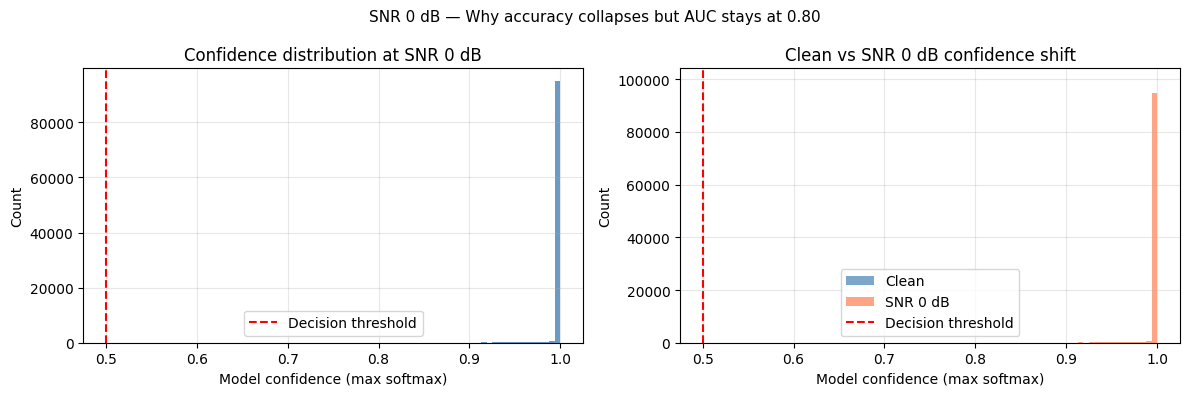

Clean   — mean confidence: 1.0000
SNR 0   — mean confidence: 0.9930
SNR 0   — % windows below 0.5 threshold: 0.0%


5758

In [19]:
# ── Confidence distribution at SNR 0 dB ───────────────────────────────────────
X_snr0 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_SNR0_X.npy'))
y_snr0 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_SNR0_y.npy'))

prob_snr0 = model_ms.predict(X_snr0, batch_size=BATCH_SIZE, verbose=0)
conf_snr0 = np.max(prob_snr0, axis=1)   # confidence = max softmax value

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SNR 0 dB — Why accuracy collapses but AUC stays at 0.80', fontsize=11)

# Confidence histogram
ax1.hist(conf_snr0, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
ax1.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold')
ax1.set_xlabel('Model confidence (max softmax)')
ax1.set_ylabel('Count')
ax1.set_title('Confidence distribution at SNR 0 dB')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Compare confidence at clean vs SNR 0
X_clean = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_X.npy'))
prob_clean = model_ms.predict(X_clean, batch_size=BATCH_SIZE, verbose=0)
conf_clean = np.max(prob_clean, axis=1)
del X_clean

ax2.hist(conf_clean, bins=80, alpha=0.7, label='Clean', color='steelblue', edgecolor='none')
ax2.hist(conf_snr0,  bins=80, alpha=0.7, label='SNR 0 dB', color='coral', edgecolor='none')
ax2.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold')
ax2.set_xlabel('Model confidence (max softmax)')
ax2.set_ylabel('Count')
ax2.set_title('Clean vs SNR 0 dB confidence shift')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'snr0_confidence_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Clean   — mean confidence: {conf_clean.mean():.4f}')
print(f'SNR 0   — mean confidence: {conf_snr0.mean():.4f}')
print(f'SNR 0   — % windows below 0.5 threshold: {(conf_snr0 < 0.5).mean()*100:.1f}%')

del X_snr0, y_snr0, prob_snr0
gc.collect()

In [20]:
# ── Noise-augmented retraining ────────────────────────────────────────────────
# Mix clean + SNR 10 + SNR 0 training data so the model learns
# what noise looks like and stops mapping it confidently to one class

def load_session_snr(session, mod, snr_tag, preprocessed_path):
    X = np.load(os.path.join(preprocessed_path, session, f'{mod}_{snr_tag}_X.npy'))
    y = np.load(os.path.join(preprocessed_path, session, f'{mod}_{snr_tag}_y.npy'))
    return X, y

# Load clean + SNR10 + SNR0 from BOTH sessions
parts_X, parts_y = [], []
for sess in ['S1', 'S2']:
    for tag in ['clean', 'SNR10', 'SNR0']:
        Xt, yt = load_session_snr(sess, MODULATION, tag, PREPROCESSED)
        parts_X.append(Xt)
        parts_y.append(yt)
        print(f'  Loaded {sess}/{tag}: {Xt.shape[0]:,} windows')
        del Xt, yt

X_aug = np.concatenate(parts_X, axis=0)
y_aug = np.concatenate(parts_y, axis=0)
del parts_X, parts_y
gc.collect()

print(f'\nAugmented pool: {X_aug.shape[0]:,} windows')

# Split
X_tr_aug, X_te_aug, y_tr_aug, y_te_aug = train_test_split(
    X_aug, y_aug, test_size=0.15, stratify=y_aug, random_state=RANDOM_SEED)
X_tr_aug, X_val_aug, y_tr_aug, y_val_aug = train_test_split(
    X_tr_aug, y_tr_aug, test_size=0.15, stratify=y_tr_aug, random_state=RANDOM_SEED)
del X_aug, y_aug
gc.collect()

print(f'Train: {X_tr_aug.shape[0]:,}  Val: {X_val_aug.shape[0]:,}  Test: {X_te_aug.shape[0]:,}')

# Retrain
model_aug = build_cnn(learning_rate=LEARNING_RATE)
model_aug_path = os.path.join(OUTPUT_DIR, 'best_model_augmented.keras')

history_aug = model_aug.fit(
    X_tr_aug, y_tr_aug,
    validation_data=(X_val_aug, y_val_aug),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(model_aug_path, monitor='val_loss',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)

print(f'Best val acc: {max(history_aug.history["val_accuracy"])*100:.2f}%')

# SNR sweep on full S2 with augmented model
print(f'\n{"SNR":<15} {"Accuracy":>10} {"AUC":>8}')
print('-' * 36)
for snr in [None, 20, 10, 0]:
    tag   = 'clean' if snr is None else f'SNR{snr}'
    Xs2   = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_X.npy'))
    ys2   = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_y.npy'))
    _, acc_a = model_aug.evaluate(Xs2, ys2, batch_size=BATCH_SIZE, verbose=0)
    prob_a   = model_aug.predict(Xs2, batch_size=BATCH_SIZE, verbose=0)
    fpr_a, tpr_a, _ = roc_curve(ys2, prob_a[:, 1])
    auc_a = auc(fpr_a, tpr_a)
    label = 'Clean (∞ dB)' if snr is None else f'SNR {snr} dB'
    print(f'{label:<15} {acc_a*100:>9.2f}%  {auc_a:>8.4f}')
    del Xs2, ys2, prob_a
    gc.collect()

  Loaded S1/clean: 100,000 windows
  Loaded S1/SNR10: 100,000 windows
  Loaded S1/SNR0: 100,000 windows
  Loaded S2/clean: 100,000 windows
  Loaded S2/SNR10: 100,000 windows
  Loaded S2/SNR0: 100,000 windows

Augmented pool: 600,000 windows
Train: 433,500  Val: 76,500  Test: 90,000
Epoch 1/100
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.7792 - loss: 0.5027 - val_accuracy: 0.8396 - val_loss: 0.3468 - learning_rate: 1.0000e-04
Epoch 2/100
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9018 - loss: 0.2442 - val_accuracy: 0.9419 - val_loss: 0.1494 - learning_rate: 1.0000e-04
Epoch 3/100
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9384 - loss: 0.1453 - val_accuracy: 0.9470 - val_loss: 0.1173 - learning_rate: 1.0000e-04
Epoch 4/100
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9466 - loss: 0.1150 - val_accuracy: 0.9530 - val_loss: 0.0978 - learning_rate: 1.0000e-04
Epoch 5/100
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9500 - 

---

## ✓ Experiment A Complete

### Files produced

```
Models/ExperimentA/
├── best_model.keras              ← trained model (best val_loss checkpoint)
├── experiment_A_results.json     ← all metrics at each SNR level
├── training_curves.png           ← loss + accuracy per epoch
├── clean_test_cm_roc.png         ← confusion matrix + ROC on clean test set
├── accuracy_vs_snr.png           ← accuracy and AUC across SNR levels
└── confusion_matrices_snr.png    ← 4-panel confusion matrices
```

### Next step: Cross-session test

```python
# Load the trained model and evaluate on S2 (unseen session)
model = keras.models.load_model('Models/ExperimentA/best_model.keras')

X_s2 = np.load('Preprocessed/S2/BPSK_clean_X.npy')
y_s2 = np.load('Preprocessed/S2/BPSK_clean_y.npy')

loss_s2, acc_s2 = model.evaluate(X_s2, y_s2)
print(f'Cross-session accuracy: {acc_s2*100:.2f}%')
```

> Cross-session test verifies ER-4: the fingerprint is device-intrinsic, not session-specific.